<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week4/Day4/Daily_Challenge_W4_D4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Daily Challenge:** Mastering Data Visualization (US Cars Dataset)



In [24]:
#Data Loading and Cleaning:

from google.colab import files
files.upload()

!unzip US_Cars_Dataset.zip

Saving US_Cars_Dataset.zip to US_Cars_Dataset (1).zip
Archive:  US_Cars_Dataset.zip
replace USA_cars_datasets.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


1. Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display all columns
pd.set_option("display.max_columns", None)

2. Load the Dataset

In [5]:
# Load dataset
df = pd.read_csv("USA_cars_datasets.csv")

# Preview
df.head()

,Unnamed: 0,price,brand,model,year,title_status,mileage,color,vin,lot,state,country,condition
0,0,6300,toyota,cruiser,2008,clean vehicle,274117.0,black,jtezu11f88k007763,159348797,new jersey,usa,10 days left
1,1,2899,ford,se,2011,clean vehicle,190552.0,silver,2fmdk3gc4bbb02217,166951262,tennessee,usa,6 days left
2,2,5350,dodge,mpv,2018,clean vehicle,39590.0,silver,3c4pdcgg5jt346413,167655728,georgia,usa,2 days left
3,3,25000,ford,door,2014,clean vehicle,64146.0,blue,1ftfw1et4efc23745,167753855,virginia,usa,22 hours left
4,4,27700,chevrolet,1500,2018,clean vehicle,6654.0,red,3gcpcrec2jg473991,167763266,florida,usa,22 hours left


3. Inspect and Clean Data

In [6]:
#Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    2499 non-null   int64  
 1   price         2499 non-null   int64  
 2   brand         2499 non-null   object 
 3   model         2499 non-null   object 
 4   year          2499 non-null   int64  
 5   title_status  2499 non-null   object 
 6   mileage       2499 non-null   float64
 7   color         2499 non-null   object 
 8   vin           2499 non-null   object 
 9   lot           2499 non-null   int64  
 10  state         2499 non-null   object 
 11  country       2499 non-null   object 
 12  condition     2499 non-null   object 
dtypes: float64(1), int64(4), object(8)
memory usage: 253.9+ KB


In [7]:
#Missing Values
df.isnull().sum()

,0
Unnamed: 0,0
price,0
brand,0
model,0
year,0
title_status,0
mileage,0
color,0
vin,0
lot,0


In [8]:
#Basic Statistics
df.describe()

,Unnamed: 0,price,year,mileage,lot
count,2499.000000,2499.000000,2499.000000,2.499000e+03,2.499000e+03
mean,1249.000000,18767.671469,2016.714286,5.229869e+04,1.676914e+08
std,721.543484,12116.094936,3.442656,5.970552e+04,2.038772e+05
min,0.000000,0.000000,1973.000000,0.000000e+00,1.593488e+08
25%,624.500000,10200.000000,2016.000000,2.146650e+04,1.676253e+08
50%,1249.000000,16900.000000,2018.000000,3.536500e+04,1.677451e+08
75%,1873.500000,25555.500000,2019.000000,6.347250e+04,1.677798e+08
max,2498.000000,84900.000000,2020.000000,1.017936e+06,1.678055e+08


In [9]:
#Handle Missing Values
# Remove rows missing critical fields
df = df.dropna(
    subset=["price", "mileage", "brand"]
)

In [10]:
#Standardize Column Names
#Depending on your dataset version:

df.columns = df.columns.str.lower()

print(df.columns)

Index(['unnamed: 0', 'price', 'brand', 'model', 'year', 'title_status',
       'mileage', 'color', 'vin', 'lot', 'state', 'country', 'condition'],
      dtype='object')


4. Histogram: Distribution of Car Prices

Matplotlib Histogram

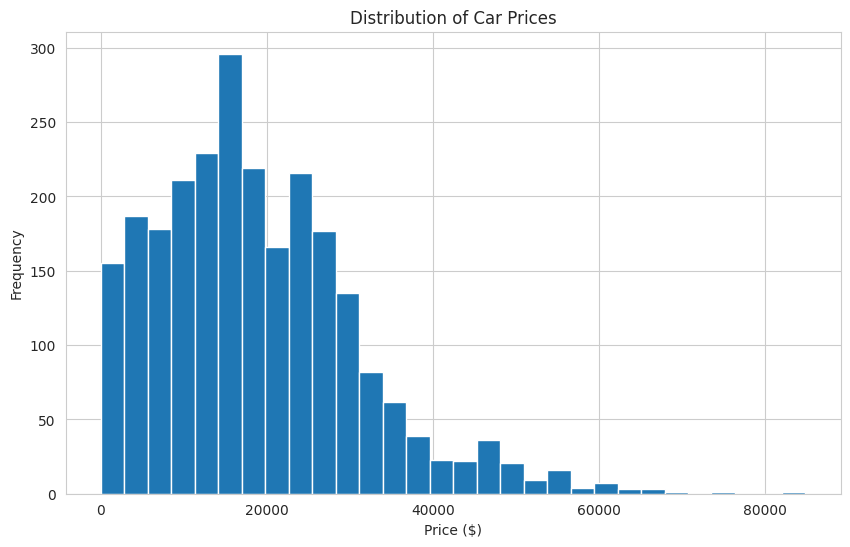

In [11]:
plt.figure(figsize=(10,6))

plt.hist(
    df["price"],
    bins=30
)

plt.title("Distribution of Car Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

plt.show()

Seaborn Histogram with KDE

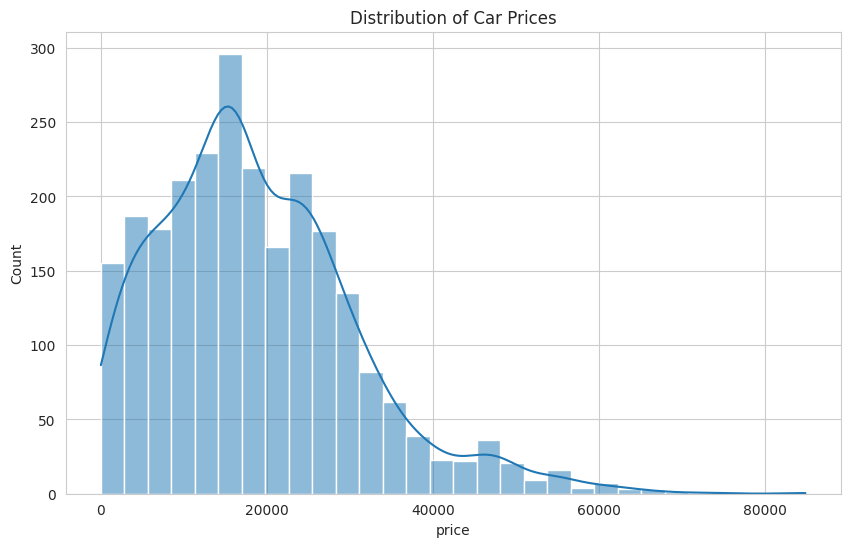

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="price",
    bins=30,
    kde=True
)

plt.title("Distribution of Car Prices")

plt.show()

Interpretation
* Most cars are concentrated in lower price ranges.
* The distribution is usually right-skewed.
* A few luxury vehicles create long tails

5. Box Plot: Price Distribution by Brand
Top 10 Brands by Frequency

In [13]:
top_brands = (
    df["brand"]
    .value_counts()
    .head(10)
    .index
)

top_df = df[
    df["brand"].isin(top_brands)
]

Seaborn Box Plot

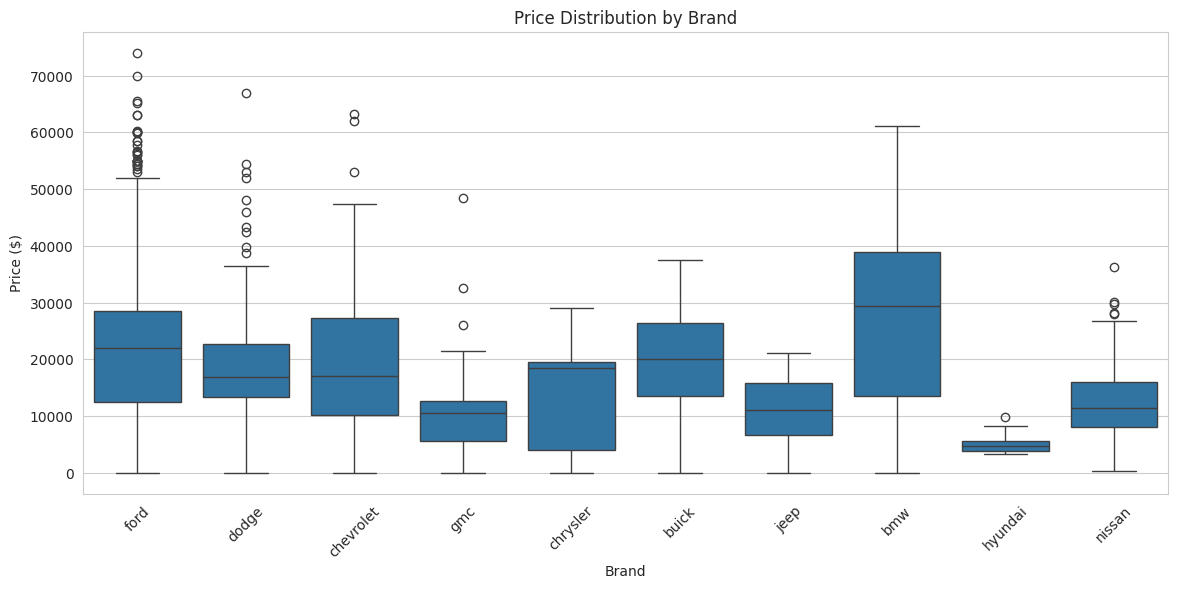

In [14]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=top_df,
    x="brand",
    y="price"
)

plt.xticks(rotation=45)

plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Price ($)")

plt.show()

Interpretation

This plot reveals:

* Median price for each brand.
* Price variability.
* Luxury brands with higher medians.
* Outliers representing premium models.

6. Interactive Scatter Plot: Price vs Mileage

Plotly Interactive Visualization

In [15]:
fig = px.scatter(
    df,
    x="mileage",
    y="price",
    color="condition",
    hover_data=[
        "brand",
        "model",
        "year"
    ],
    title="Price vs Mileage by Vehicle Condition"
)

fig.show()

Interpretation

Expected pattern:

* Higher mileage generally lowers price.
* Newer vehicles maintain higher prices.
* Better-condition vehicles cluster at higher prices.

7. Additional Scatter Plot with Seaborn

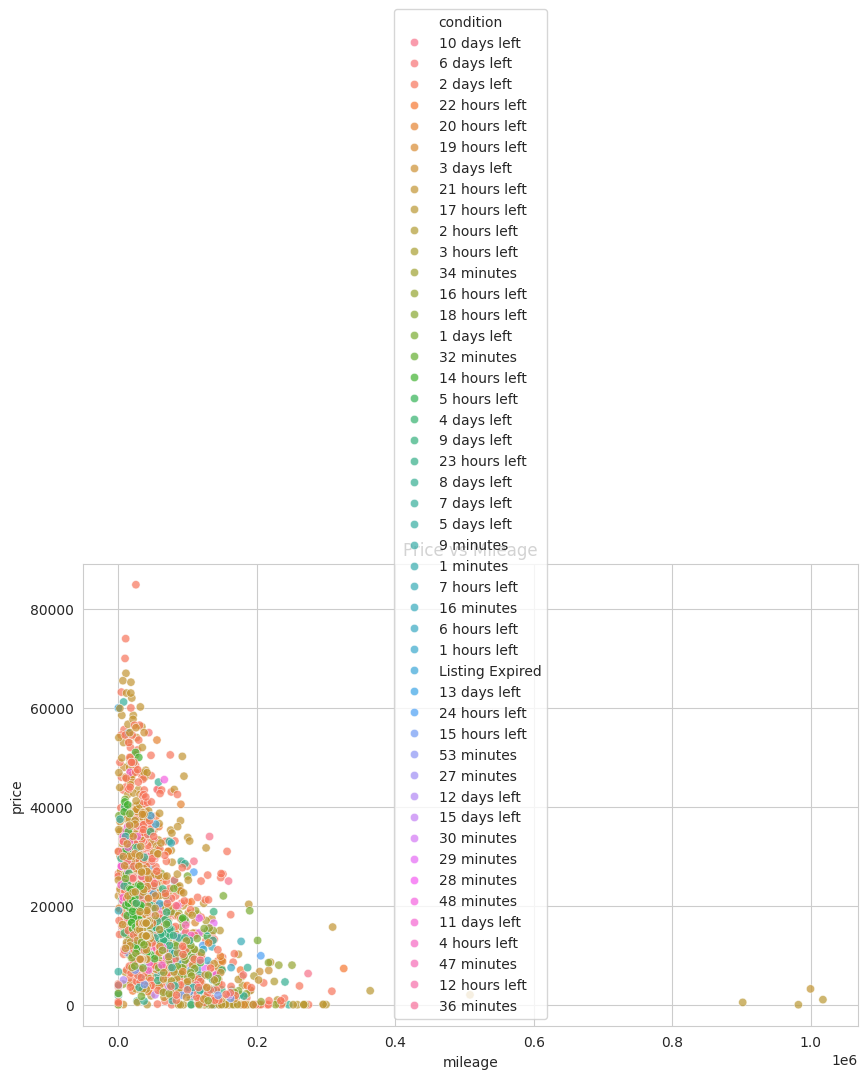

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="mileage",
    y="price",
    hue="condition",
    alpha=0.7
)

plt.title("Price vs Mileage")

plt.show()

8. Optional: Heatmap of Average Prices

Average Price by Brand and Condition

In [17]:
heatmap_data = (
    df.pivot_table(
        values="price",
        index="brand",
        columns="condition",
        aggfunc="mean"
    )
)

Select Top Brands

In [18]:
top_brands = (
    df["brand"]
    .value_counts()
    .head(10)
    .index
)

heatmap_data = heatmap_data.loc[top_brands]

Heatmap

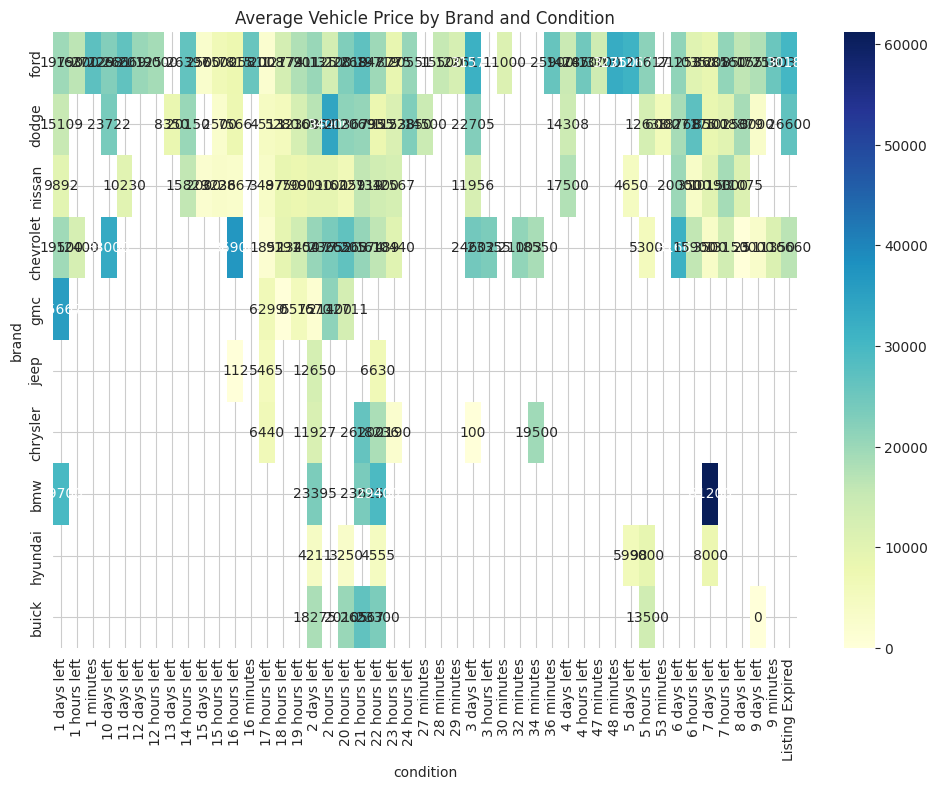

In [19]:
plt.figure(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Vehicle Price by Brand and Condition")

plt.show()

Interpretation

The heatmap helps identify:

* Brands that retain value.
* Conditions associated with premium pricing.
* Which brands depreciate most.

9. Bonus: Top 10 Brands by Average Price

In [20]:
avg_price = (
    df.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

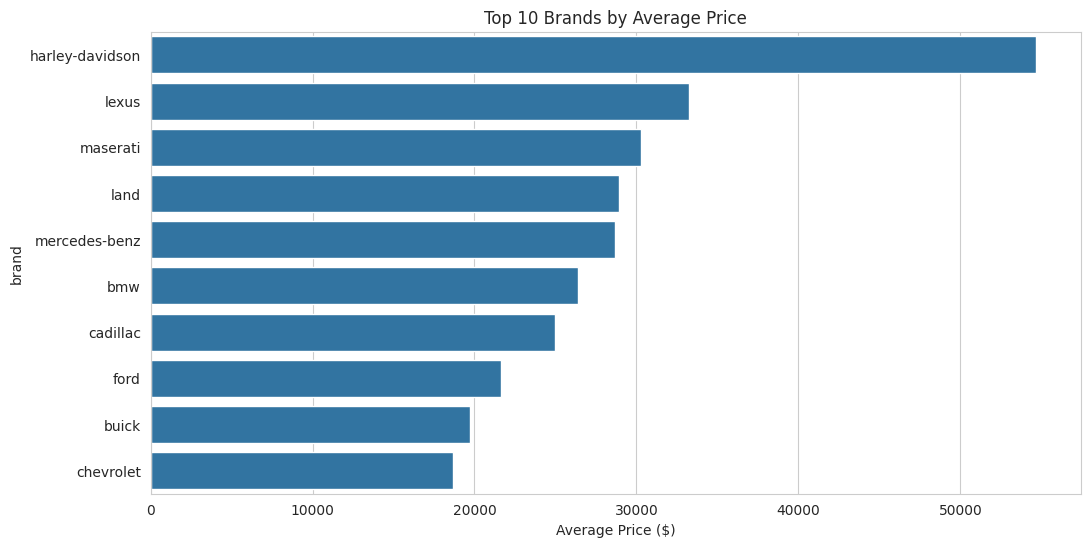

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=avg_price.values,
    y=avg_price.index
)

plt.title("Top 10 Brands by Average Price")
plt.xlabel("Average Price ($)")

plt.show()

10. Bonus: Average Price by Vehicle Age

In [22]:
#Create age variable:

current_year = pd.Timestamp.now().year

df["vehicle_age"] = (
    current_year - df["year"]
)

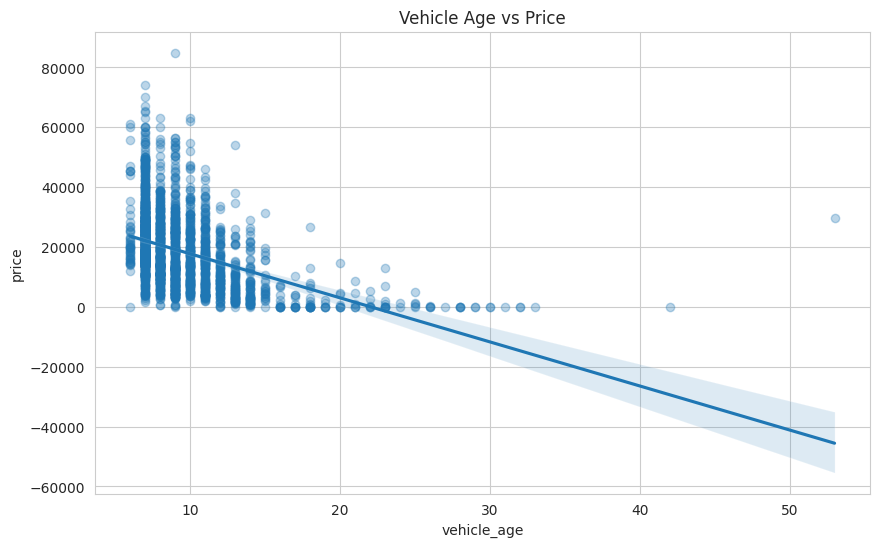

In [23]:
#Visualization
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x="vehicle_age",
    y="price",
    scatter_kws={"alpha":0.3}
)

plt.title("Vehicle Age vs Price")

plt.show()

Interpretation

Shows depreciation trends over time.